<a href="https://colab.research.google.com/github/Aaaaddddyyyyyyyy/Deep-Learning/blob/main/Dropouts_in_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import tensorflow as trf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

Dropout on regression

In [3]:
## Generate data

X_train= np.linspace(-1,1,20)


In [4]:
y_train=np.array([-0.6561,-0.3999,-0.4321,-0.1933,-0.9001,
                  -0.3214,-0.2002,-0.3110,-0.9002,-0.4921,
                  -0.9875,-0.4321,-0.9898,-0.8989,-0.4657,
                  -0.9085,-0.3210,-0.9876,-0.0009,-0.1234,
                  -0.9001,-0.9875,-0.2002,-0.8989,0.6561])

In [5]:
X_test=np.linspace(-1,1,20)

In [6]:
y_test= np.array([-0.3999,-0.4321,-0.1933,-0.9001,-0.0009,
                  -0.3214,-0.2002,-0.3110,-0.9002,-0.4921,
                  -0.9875,-0.4321,-0.9898,-0.8989,-0.4657,
                  -0.9085,-0.3210,-0.9876,-0.0009,-0.1234,
                  -0.9001,-0.9875,-0.9876,-0.4563,-0.3546])

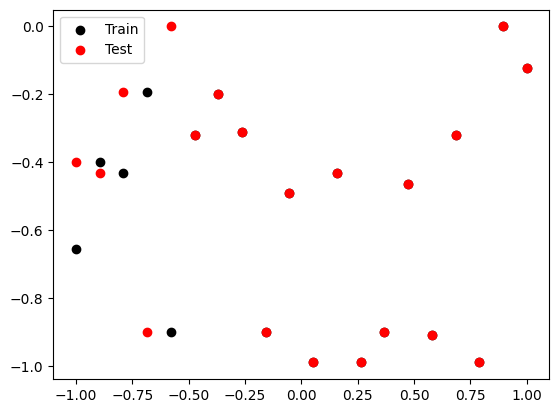

In [7]:
plt.scatter(X_train, y_train[:len(X_train)], c='black', label='Train')
plt.scatter(X_test, y_test[:len(X_test)], c='red', label='Test')
plt.legend()
plt.show()

Regression model

In [8]:
from re import VERBOSE
model= Sequential()
model.add(Dense(128, input_dim=1,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='linear'))
adam= Adam(learning_rate=0.01)
model.compile(loss='mse',optimizer='Adam',metrics=['mse'])
history=model.fit(X_train, y_train[:len(X_train)], epochs=500,validation_data= (X_test, y_test[:len(X_test)]),verbose=False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
## evaluate the model
train_mse=  model.evaluate(X_train,y_train[:len(X_train)],verbose=0)
test_mse=model.evaluate(X_test,y_test[:len(X_test)],verbose=0)
print('Train: {}, Test : {}'.format(train_mse,test_mse))

Train: [0.056549571454524994, 0.056549571454524994], Test : [0.06473878771066666, 0.06473878771066666]


In [12]:
y_pred=model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


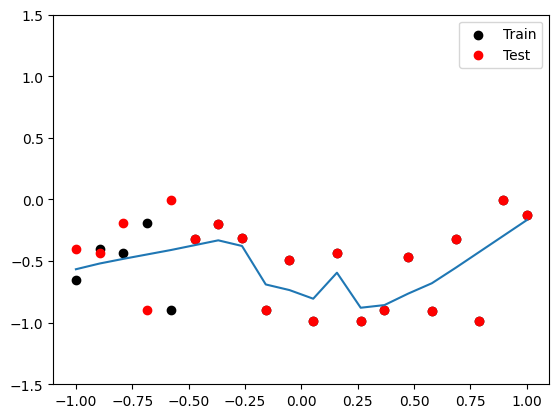

In [16]:
plt.figure()
plt.scatter(X_train,y_train[:len(X_train)],c='black', label="Train")
plt.scatter(X_test,y_test[:len(X_test)],c= 'red',label='Test')
plt.plot(X_test,y_pred)
plt.legend()
plt.ylim(-1.5, 1.5)
plt.show()

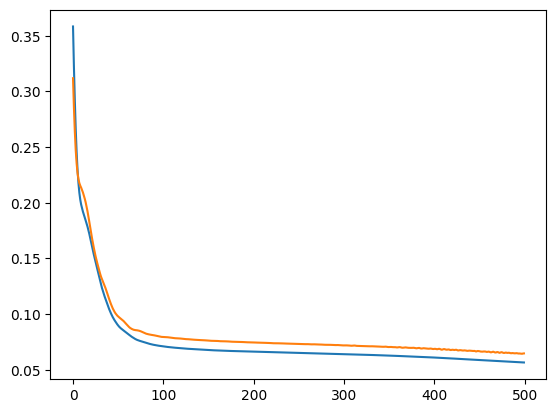

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

Dropout model

In [20]:
model= Sequential()
model.add(Dense(128,input_dim=1,activation='relu'))   # hidden layer1
model.add(Dropout(0.2))
model.add(Dense(128,activation='relu'))               # hidden layer 2
model.add(Dropout(0.2))
model.add(Dense(1,activation='linear'))       ## output layer
adam= Adam(learning_rate=0.2)

model.compile(loss='mse',optimizer='Adam',metrics=['mse'])
history=model.fit(X_train,y_train[:len(X_train)],epochs=500,validation_data=(X_test,y_test[:len(X_test)]),verbose=False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
## evaluate ther model
train_mse=model.evaluate(X_train,y_train[:len(X_train)],verbose=0)
test_mse=model.evaluate(X_test,y_test[:len(X_test)],verbose=0)
print("Train : {}, Test : {}".format(train_mse,test_mse))

Train : [0.06444139778614044, 0.06444139778614044], Test : [0.07288195192813873, 0.07288195192813873]


In [23]:
y_pred=model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


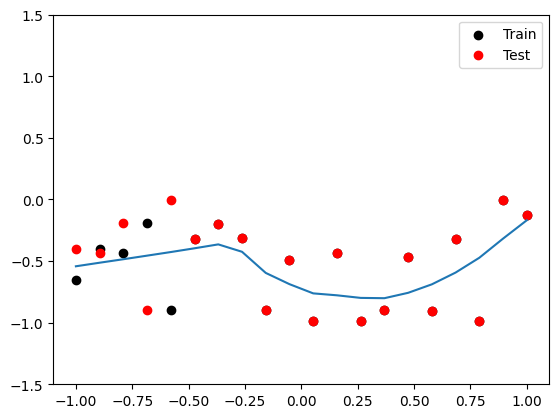

In [24]:
plt.figure()
plt.scatter(X_train,y_train[:len(X_train)],c='black', label="Train")
plt.scatter(X_test,y_test[:len(X_test)],c= 'red',label='Test')
plt.plot(X_test,y_pred)
plt.legend()
plt.ylim(-1.5, 1.5)
plt.show()